<a href="https://colab.research.google.com/github/haniyathul/Praktikum-Analisis-Deret-Waktu/blob/main/Tugas_Praktikum_STA2542_Minggu_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRAKTIKUM 1 ANALISIS DERET WAKTU
# HANIYATHUL HUSNA (M0501251011)

catatan: data simulasi
seed(1011)
parameter = +11

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [99]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1011)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 0.5+11
beta0 = 10+11
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})
df

,Time,Value
0,2017-01-31,18.691582
1,2017-02-28,35.645269
2,2017-03-31,42.284487
3,2017-04-30,56.059628
4,2017-05-31,66.801181
...,...,...
95,2024-12-31,1115.560875
96,2025-01-31,1126.489830
97,2025-02-28,1133.592021
98,2025-03-31,1148.464826


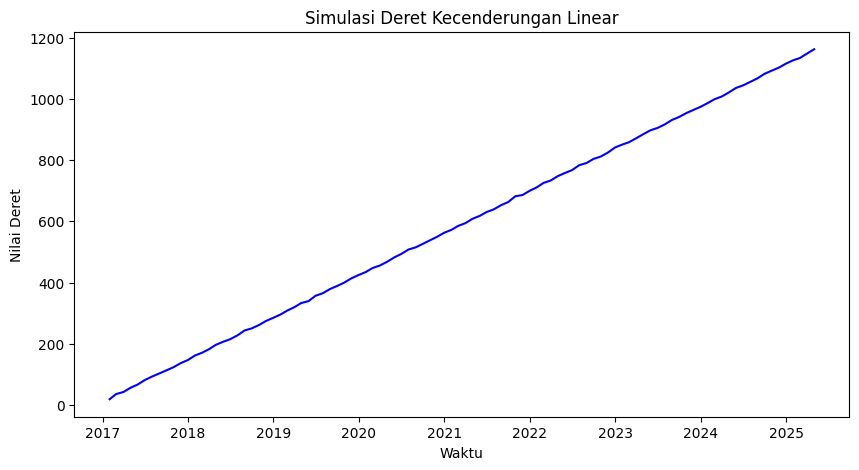

In [100]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Cek apakah ada korelasi antar pengamatan?

Dari grafik:

Nilai deret meningkat secara konsisten dari waktu ke waktu.
Pengamatan yang berdekatan memiliki nilai yang relatif berdekatan, sehingga menunjukkan ketergantungan antar pengamatan.
Polanya hampir membentuk garis lurus, sehingga korelasi antar waktu kemungkinan sangat kuat dan positif.
Namun, grafik saja belum cukup untuk memastikan autokorelasi. Korelasi tersebut bisa terutama disebabkan oleh tren (nonstasioneritas)..

In [102]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


Berdasarkan hasil perhitungan, diperoleh nilai korelasi antara waktu dan nilai deret sebesar 1,0000. Nilai tersebut menunjukkan adanya hubungan linear positif yang sempurna antara waktu dan nilai deret. Artinya, peningkatan waktu selalu diikuti oleh peningkatan nilai deret secara konsisten. Hasil ini mengindikasikan adanya kecenderungan (trend) linear yang sangat kuat pada deret waktu.

In [51]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.325e+06
Date:                Wed, 02 Sep 2026   Prob (F-statistic):          8.02e-224
Time:                        02:11:27   Log-Likelihood:                -200.80
No. Observations:                 100   AIC:                             405.6
Df Residuals:                      98   BIC:                             410.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           21.1123      0.361     58.416   

**Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?**

Model yang diperoleh adalah:
Model yang dipaskan adalah:

$$ \hat{Value}=21.1123+11.5016(Time\_Numeric) $$

Jadi hasil estimasi parameternya:
Artinya, setiap pertambahan 1 satuan waktu, nilai Value meningkat sekitar 11,50 satuan.

Karena dari simulasi grafik terlihat deret memang dibuat dengan kecenderungan linear yang sangat kuat, hasil estimasi tersebut menunjukkan bahwa model berhasil menangkap parameter dan pola linear asli dengan sangat baik.

**Apakah model regresi yang dipaskan sudah bagus?**

$R^2$ sebesar 1,000 yang menunjukkan bahwa hampir seluruh variasi nilai deret dapat dijelaskan oleh waktu.

Koefisien waktu juga signifikan secara statistik dengan p-value < 0,001. Selain itu, nilai Durbin-Watson sebesar 2,350 menunjukkan tidak adanya indikasi autokorelasi residual yang kuat, sedangkan uji Jarque-Bera menghasilkan p-value sebesar 0,178 sehingga residual tidak menunjukkan penyimpangan yang signifikan dari normalitas. Dengan demikian, model regresi yang dipaskan dapat dikatakan sangat baik dalam menggambarkan pola linear pada data simulasi.

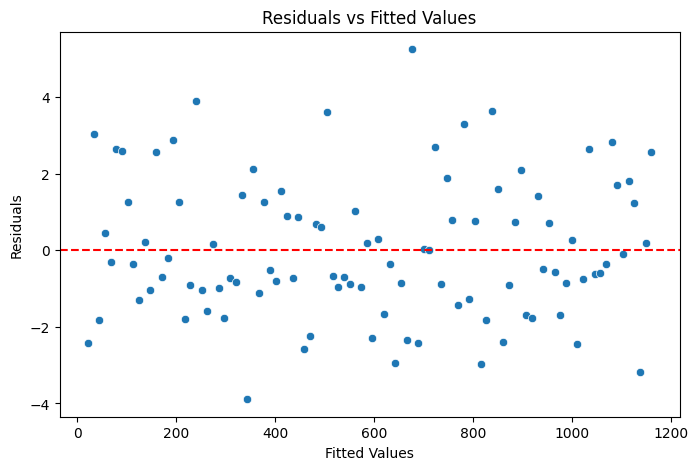

In [103]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


**Apa interpretasi dari plot tersebut?**

Berdasarkan plot Residuals vs Fitted Values, residual terlihat menyebar secara acak di sekitar garis nol dan tidak membentuk pola sistematis tertentu. Penyebaran residual juga relatif merata pada berbagai nilai fitted value sehingga tidak terdapat indikasi kuat adanya pelanggaran asumsi linearitas maupun heteroskedastisitas. Dengan demikian, model regresi linear yang digunakan telah mampu menggambarkan pola hubungan antara waktu dan nilai deret dengan cukup baik.

In [105]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.9765


**Apa kesimpulan dari nilai uji Breusch Pagan tersebut?**

Hasil uji Breusch-Pagan:

p-value = 0,9765

Dengan taraf signifikansi α = 5% (0,05):

H₀: tidak terdapat heteroskedastisitas , varians residual konstan (homoskedastisitas)
H₁: terdapat heteroskedastisitas , varians residual tidak konstan

Karena:

$$ 0,9765 > 0,05 $$

maka H₀ tidak ditolak.

Kesimpulan

Tidak terdapat bukti adanya heteroskedastisitas pada model regresi. Dengan kata lain, residual dapat dianggap memiliki varians yang konstan (homoskedastisitas).

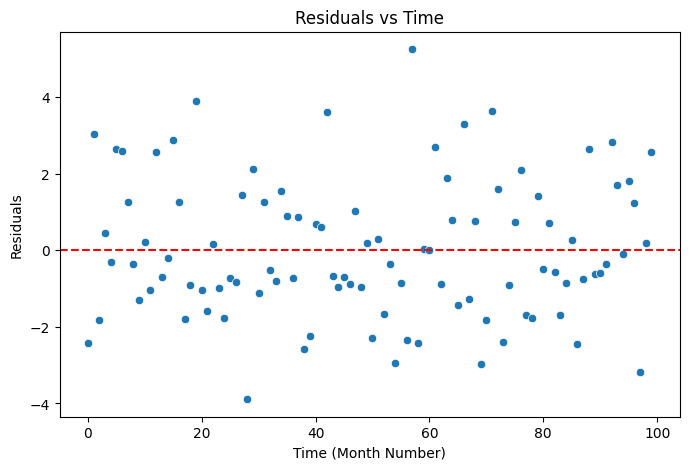

In [54]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

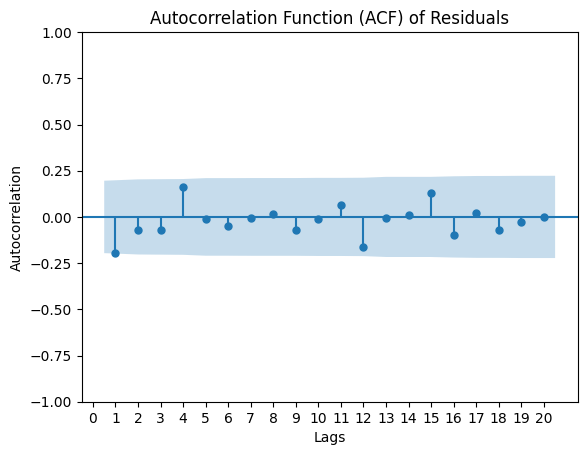

In [55]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


**Apa yang dapat Anda simpulkan dari plot di atas?**
1. Plot Residuals vs Time

Residual terlihat menyebar di sekitar garis nol (0) dan tidak menunjukkan pola tertentu, seperti tren naik/turun atau pola berulang yang jelas. Sebagian besar residual berada di sekitar nol, meskipun terdapat beberapa residual yang cukup besar.
Kesimpulan: residual cenderung acak dan tidak menunjukkan pola sistematis terhadap waktu, sehingga asumsi independensi residual secara visual cukup terpenuhi.

2. Plot ACF Residual

Pada plot ACF, hampir seluruh nilai autokorelasi pada lag 1-20 berada di dalam batas confidence interval (area biru). Tidak ada spike yang secara jelas melewati batas tersebut.
Kesimpulan: tidak terdapat autokorelasi yang signifikan pada residual. Dengan demikian, residual dapat dianggap tidak memiliki ketergantungan serial yang berarti.

In [106]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    3.884175   0.048743
2    4.397659   0.110933
3    4.890182   0.180017
4    7.698307   0.103276
5    7.713937   0.172722
6    7.961780   0.240917
7    7.964393   0.335744
8    7.990091   0.434439
9    8.554266   0.479393
10   8.566846   0.573644
11   9.007840   0.621169
12  12.099925   0.437688
13  12.102050   0.519294
14  12.121457   0.596549
15  14.173535   0.512411
16  15.308335   0.502182
17  15.352431   0.570113
18  15.974404   0.594334
19  16.063699   0.653024


Apa kesimpulan dari hasil uji Ljung-Box tersebut?

Khusus pada lag 1, p-value = 0.048743 < 0.05, sehingga terdapat indikasi autokorelasi pada lag 1.

Tetapi mulai lag 2 sampai lag 19, seluruh p-value > 0.05, sehingga tidak terdapat bukti autokorelasi yang signifikan pada lag-lag tersebut.

Dengan demikian, secara umum residual tidak menunjukkan autokorelasi yang kuat dan sistematis, meskipun terdapat indikasi autokorelasi pada lag pertama.

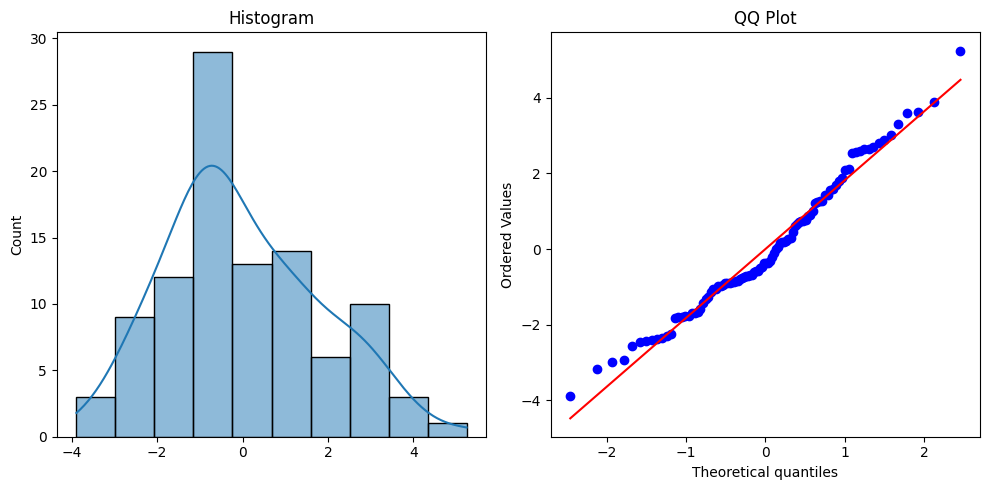

In [57]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?

1. Histogram residual

Histogram menunjukkan residual memiliki bentuk yang cukup menyerupai distribusi normal, dengan konsentrasi terbesar berada di sekitar nilai 0. Namun, distribusinya sedikit miring ke kanan dan terdapat beberapa residual yang cukup ekstrem.

2. QQ Plot

Pada QQ plot, sebagian besar titik berada cukup dekat dengan garis diagonal, terutama di bagian tengah. Namun, pada bagian ujung (tail) terlihat beberapa titik menyimpang dari garis, terutama pada ekor kanan.

Hal ini menunjukkan bahwa residual cukup mendekati distribusi normal, meskipun tidak sempurna pada bagian ekornya.

In [107]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9776104776943966, p-value = 0.0864420247417661


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

$$W=0.9776$$
$$ p\text{-value}=0.0864 $$

Dengan taraf signifikansi \(\alpha=0.05\):

$p{-value}=0.0864 > 0.05$
sehingga H₀ tidak ditolak.
H₀ menyatakan bahwa residual berdistribusi normal.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [109]:
# Menentukan parameter simulasi
np.random.seed(1011)
n_periods = 120
beta_0, beta_1, beta_2= 50+11, 0.5+11, 0.02+11
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

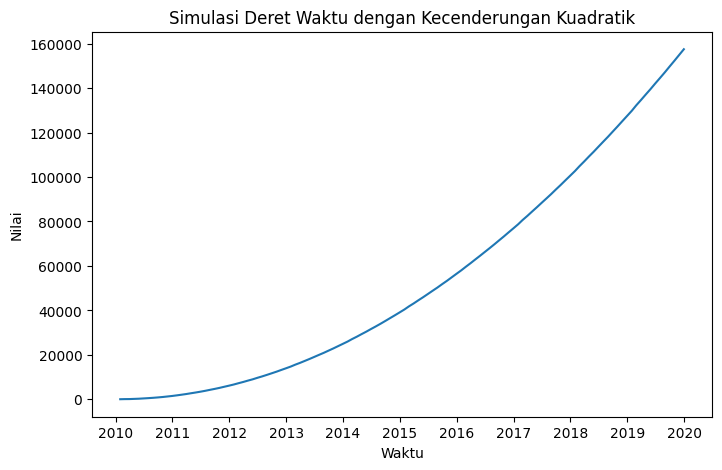

In [110]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?

Terlihat bahwa nilai deret terus meningkat seiring bertambahnya waktu, tetapi kenaikannya tidak konstan. Pada awal periode, kenaikan nilai relatif lambat, kemudian semakin lama kenaikannya semakin cepat.

Bentuk kurva yang melengkung ke atas (cekung ke atas) menunjukkan adanya kecenderungan kuadratik positif.

In [61]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.446e+09
Date:                Wed, 02 Sep 2026   Prob (F-statistic):               0.00
Time:                        02:12:39   Log-Likelihood:                -440.66
No. Observations:                 120   AIC:                             887.3
Df Residuals:                     117   BIC:                             895.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         62.6813      2.597     24.140      0.0

Model yang dipaskan:

$$ \hat y = 62.6813 + 11.4719x_1 + 11.0200x_2 $$

dengan $x_2$ kemungkinan merupakan kuadrat waktu $(Time^2)$.
Parameter	Estimasi
Intercept	62.6813
$x_1$	11.4719
$x_2$	11.0200

Ketiga parameter memiliki p-value < 0.001, sehingga baik intercept, komponen linear, maupun komponen kuadratik berpengaruh signifikan terhadap $y$.

Yang paling penting adalah koefisien $x_2 = 11.0200$ yang positif. Ini menunjukkan adanya kecenderungan kuadratik yang meningkat, sesuai dengan grafik sebelumnya yang semakin curam.

Nilai $R^2$ dan Adjusted $R^2$ sebesar 1,000 menunjukkan bahwa model mampu menjelaskan hampir seluruh variasi data. Selain itu, nilai Durbin-Watson sebesar 2,261 dan hasil uji Jarque-Bera dengan p-value 0,276 menunjukkan bahwa residual tidak menunjukkan masalah autokorelasi yang kuat maupun penyimpangan normalitas yang signifikan. Dengan demikian, model regresi kuadratik yang dipaskan dapat dikatakan sangat baik dalam menggambarkan pola deret tersebut.


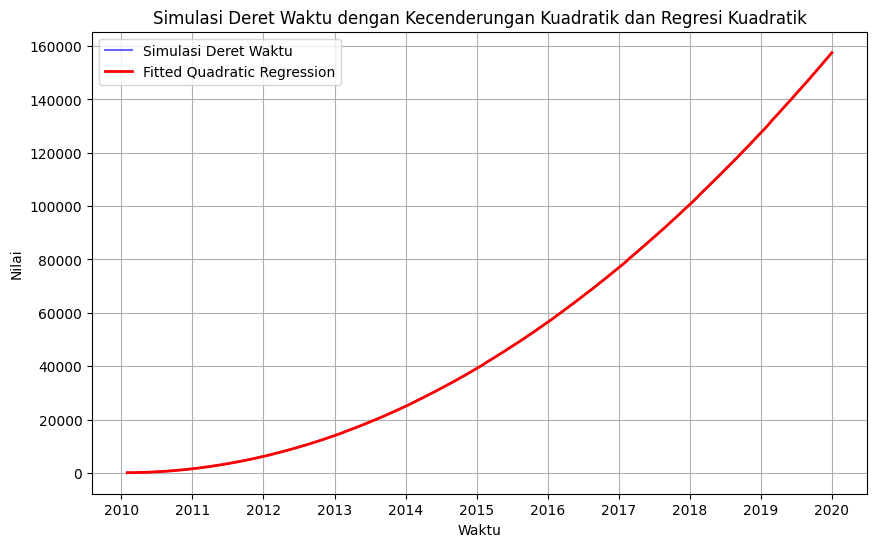

In [62]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!

Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!

Model regresi kuadratik yang dipaskan sudah tepat untuk menggambarkan deret karena mampu menangkap pola kuadratik dengan sangat baik. Hal ini terlihat dari garis fitted yang hampir berimpit dengan deret asli dan nilai \(R^2=1.000\). Hasil pemeriksaan residual juga menunjukkan bahwa residual berdistribusi mendekati normal dan tidak menunjukkan autokorelasi yang kuat. Dengan demikian, model regresi kuadratik dapat dikatakan sesuai dengan pola deret dan asumsi-asumsi model secara umum telah terpenuhi.

# cek asumsi model regresi kuadratik

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [111]:
# Menentukan parameter simulasi
np.random.seed(1011)
n_periods = 120
beta0, beta1, beta2=50+11,-25+11, -2+11
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


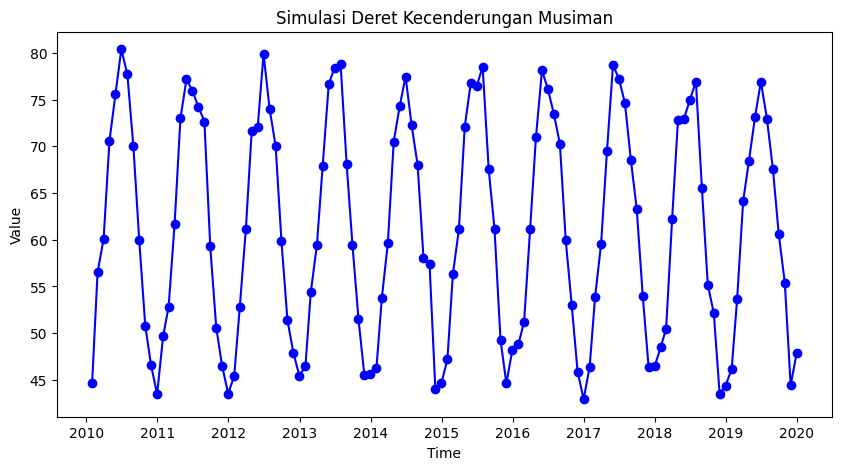

In [112]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?

Berdasarkan plot, deret menunjukkan pola musiman dengan periode 12. Nilai deret mengalami kenaikan dan penurunan secara berulang dengan pola yang relatif sama setiap 12 periode. Karena data merupakan data bulanan dan periode musimannya 12, pola tersebut menunjukkan adanya pola musiman tahunan. Terdapat periode tertentu dengan nilai yang cenderung tinggi dan periode lainnya dengan nilai yang cenderung rendah, kemudian pola tersebut berulang pada tahun berikutnya. Amplitudo fluktuasi musiman relatif stabil dari waktu ke waktu.

In [113]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [114]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [115]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [116]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     400.7
Date:                Wed, 02 Sep 2026   Prob (F-statistic):           3.79e-82
Time:                        02:52:12   Log-Likelihood:                -243.36
No. Observations:                 120   AIC:                             510.7
Df Residuals:                     108   BIC:                             544.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari       46.9478      0.613     76.598      0.0

Bagaimana interpretasi dari hasil tersebut?
1. Kualitas model

Nilai:

$$ R^2 = 0.976 $$

dan

$$ Adjusted\ R^2 = 0.974 $$

Artinya, sekitar 97,6% variasi nilai deret dapat dijelaskan oleh pola bulanan/musiman dalam model. Hanya sekitar 2,4% variasi yang tidak dijelaskan oleh model.

Selain itu:

$$ p{-value F-statistic}=3.79\times10^{-82}< 0.05$$

sehingga model secara keseluruhan signifikan.

2. Pola musiman

Seluruh koefisien bulan memiliki p-value < 0.001, sehingga perbedaan nilai antarbulan sangat signifikan.

Dari estimasinya terlihat:

Januari: sekitar 46,95
meningkat hingga Juni: sekitar 77,38 , puncak
kemudian menurun
Desember: sekitar 45,25 ,salah satu nilai terendah.

Ini sangat sesuai dengan grafik sebelumnya: nilai naik dari awal tahun, mencapai puncak sekitar pertengahan tahun, kemudian turun kembali hingga akhir tahun.

3. Asumsi residual

Normalitas:

Jarque-Bera:

$$ p=0.415>0.05 $$

tidak ada bukti residual tidak normal.

Autokorelasi:

Durbin-Watson:

$$ DW=2.175 $$

Nilai ini cukup dekat dengan 2, sehingga tidak menunjukkan autokorelasi residual yang kuat.

Residual secara keseluruhan: model sudah menangkap sebagian besar pola musiman sehingga residual relatif kecil.

In [117]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

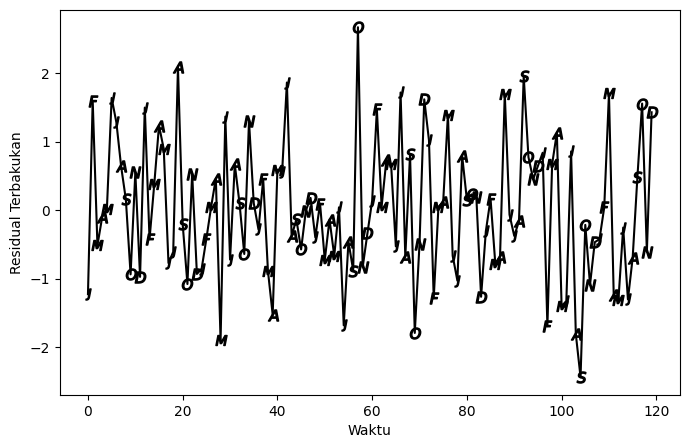

In [118]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


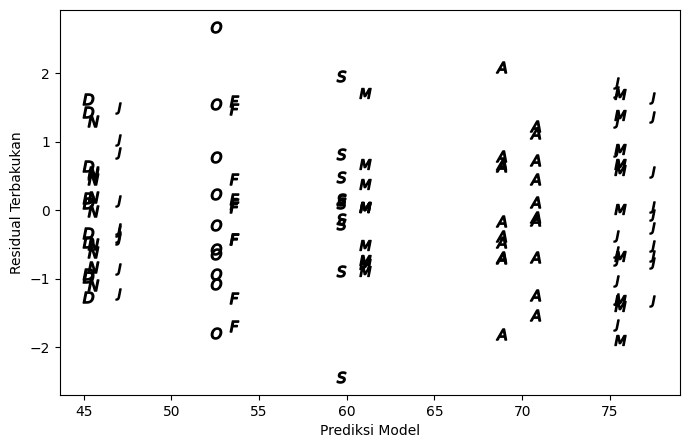

In [119]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

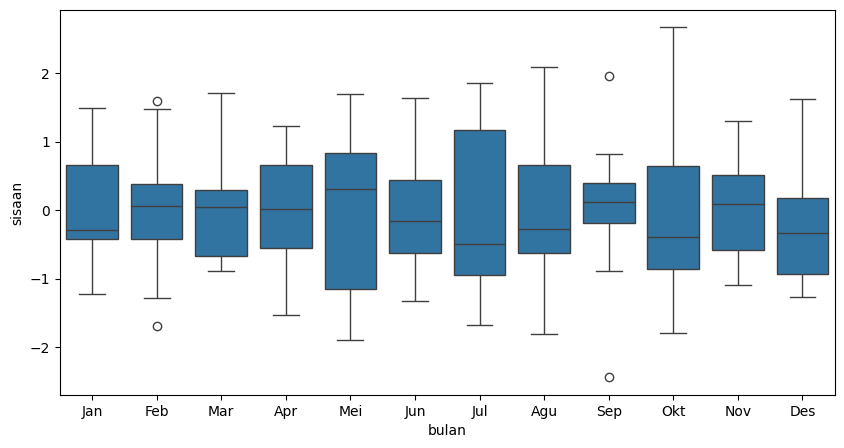

In [120]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Bagaimana interpretasi Anda terhadap tiga plot di atas?

1. Plot residual terbakukan terhadap waktu

Pada plot pertama, residual terbakukan berfluktuasi di sekitar garis nol dan tidak menunjukkan pola tertentu yang konsisten dari waktu ke waktu. Residual kadang positif dan kadang negatif, dengan sebagian besar berada pada kisaran sekitar -2 sampai 2.

Tidak terlihat adanya tren atau pola musiman yang jelas pada residual. Ini menunjukkan bahwa komponen musiman utama sudah berhasil ditangkap oleh model.

Kesimpulan: residual tidak menunjukkan pola sistematis terhadap waktu, sehingga model sudah cukup baik dalam menangkap pola yang terdapat pada deret.

2. Plot residual terbakukan terhadap prediksi model

Pada plot kedua, residual tersebar di sekitar nilai nol pada berbagai tingkat nilai prediksi. Tidak terlihat pola seperti bentuk kipas (funnel) atau pola melengkung yang jelas.

Sebaran residual juga relatif acak, meskipun terdapat beberapa nilai residual yang cukup besar.

Kesimpulan: tidak terlihat adanya pola sistematis antara residual dan nilai prediksi, sehingga tidak ada indikasi kuat adanya masalah heteroskedastisitas secara visual.

3. Boxplot residual berdasarkan bulan

Plot ketiga memperlihatkan distribusi residual untuk masing-masing bulan.

Secara umum, median residual setiap bulan berada cukup dekat dengan nol. Sebaran residual antarbulan memang berbeda-beda, tetapi tidak terlihat perbedaan yang sangat ekstrem secara umum. Beberapa bulan, seperti Februari, September, dan Oktober, memiliki titik yang cukup ekstrem (outlier).

Namun, keberadaan beberapa outlier tersebut tidak serta-merta menunjukkan bahwa model tidak tepat. Yang lebih penting adalah apakah residual menunjukkan pola musiman yang tersisa. Dari boxplot, tidak terlihat pola residual yang konsisten berdasarkan bulan.

Kesimpulan: residual pada masing-masing bulan secara umum masih berpusat di sekitar nol dan tidak menunjukkan pola musiman yang kuat. Terdapat beberapa outlier, tetapi secara keseluruhan pola residual masih cukup acak.


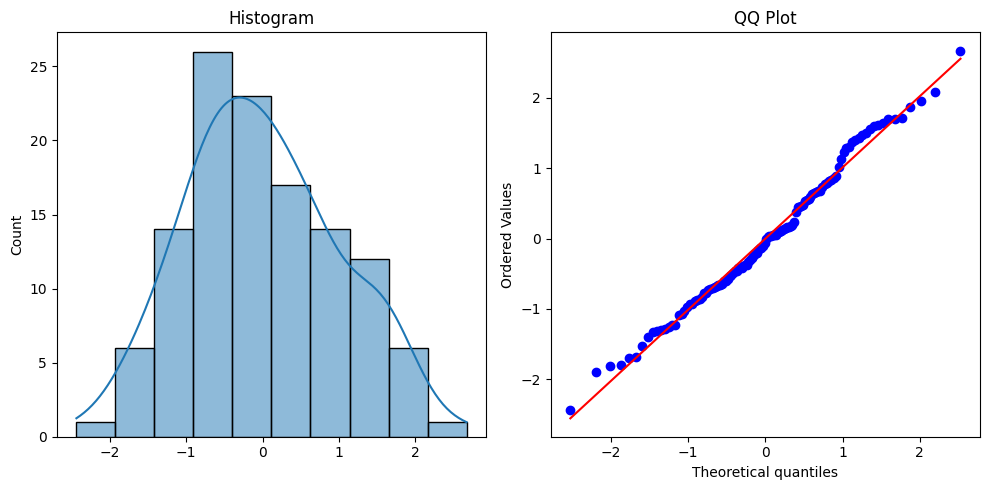

In [73]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

Hitunglah statistik uji untuk mengecek asumsi model

In [74]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

In [75]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [76]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     400.7
Date:                Wed, 02 Sep 2026   Prob (F-statistic):           3.79e-82
Time:                        02:14:03   Log-Likelihood:                -243.36
No. Observations:                 120   AIC:                             510.7
Df Residuals:                     108   BIC:                             544.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.9478      0.613     76.598      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

Apakah model dengan intersep sudah memenuhi asumsi regresi?

In [ ]:
# uji asumsi model dengan intersep

## Kecenderungan Linear dan Musiman

In [77]:
# Parameter
np.random.seed(1011)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5+11, 10+11 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


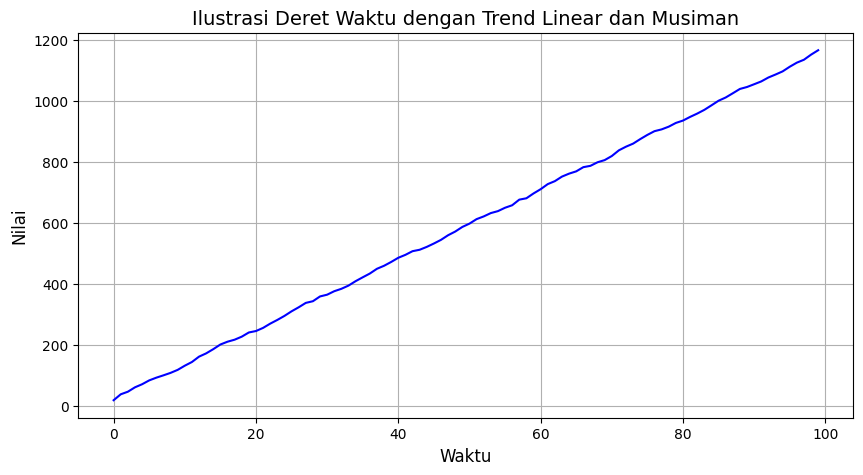

In [78]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [79]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [80]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [81]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.702e+05
Date:                Wed, 02 Sep 2026   Prob (F-statistic):          2.53e-193
Time:                        02:14:32   Log-Likelihood:                -196.09
No. Observations:                 100   AIC:                             418.2
Df Residuals:                      87   BIC:                             452.0
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari       20.9587      0.687     30.509      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?

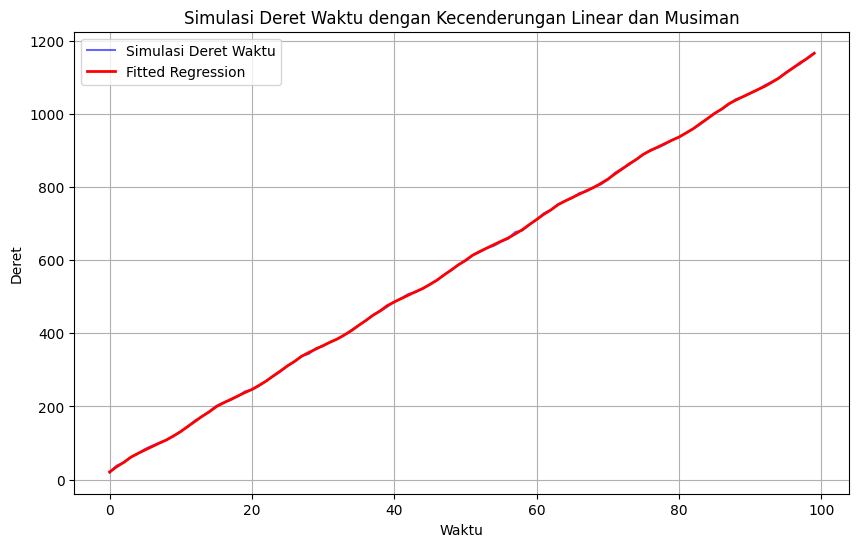

In [82]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

In [ ]:
# uji asumsi model

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [83]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

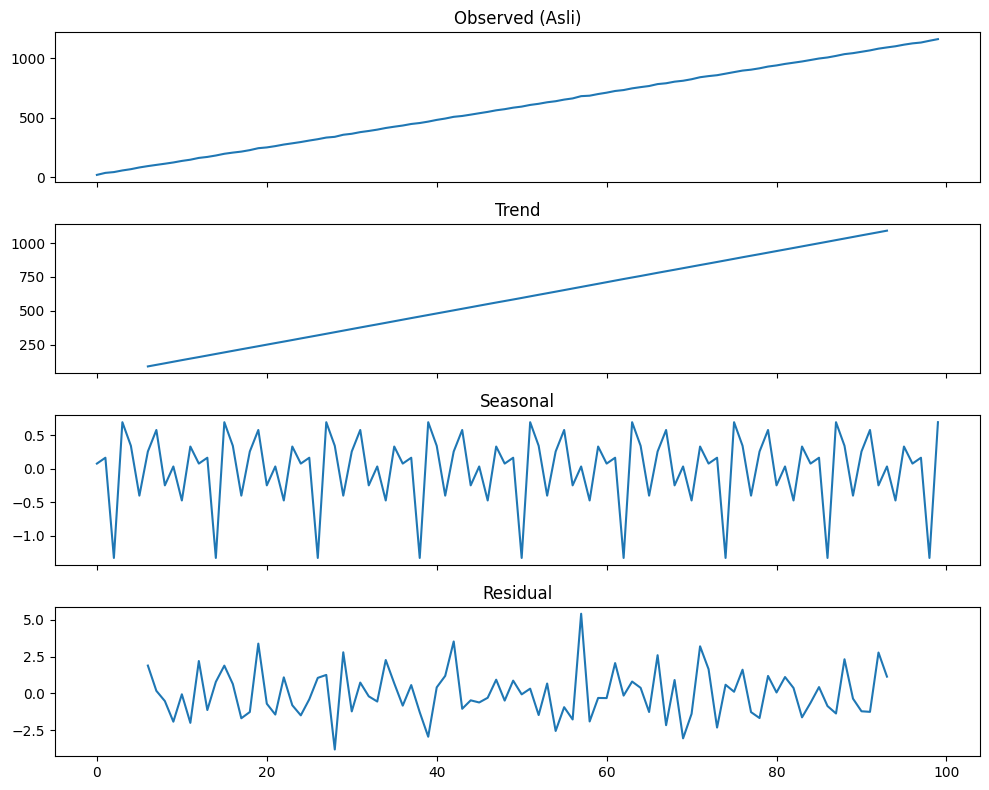

In [84]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?

In [85]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

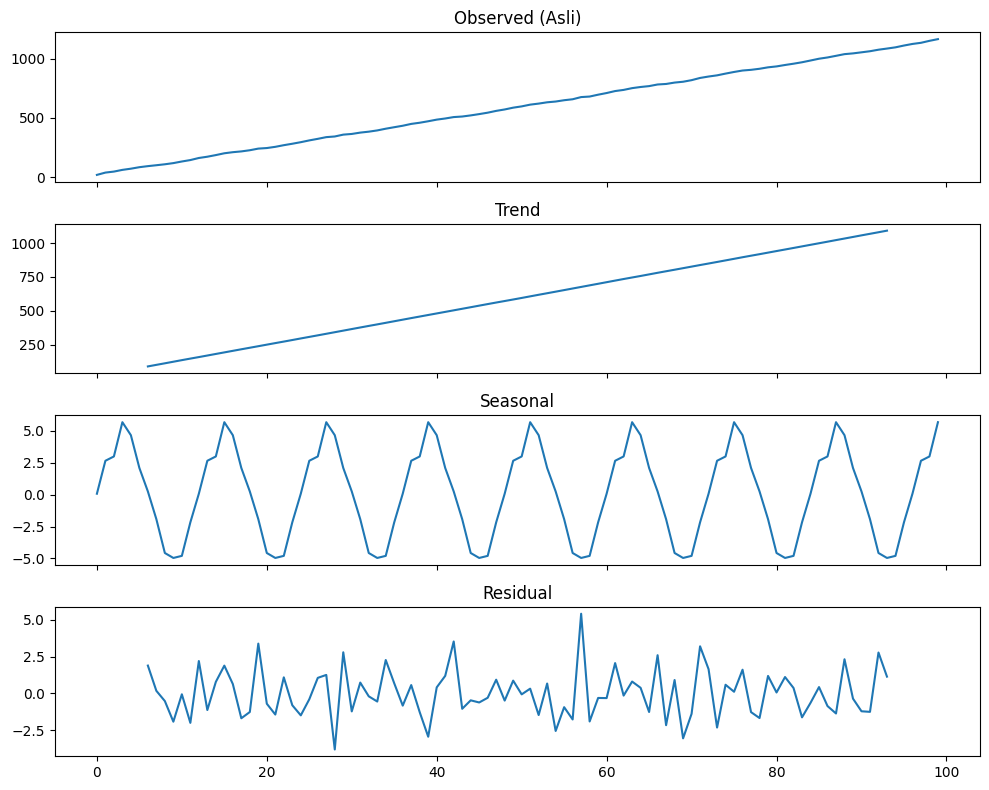

In [86]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [88]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1011)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05+11, 10+11 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

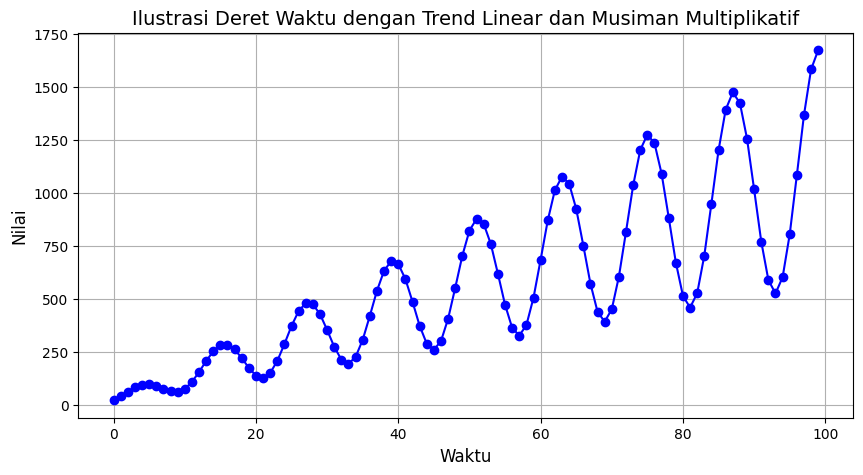

In [89]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [90]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

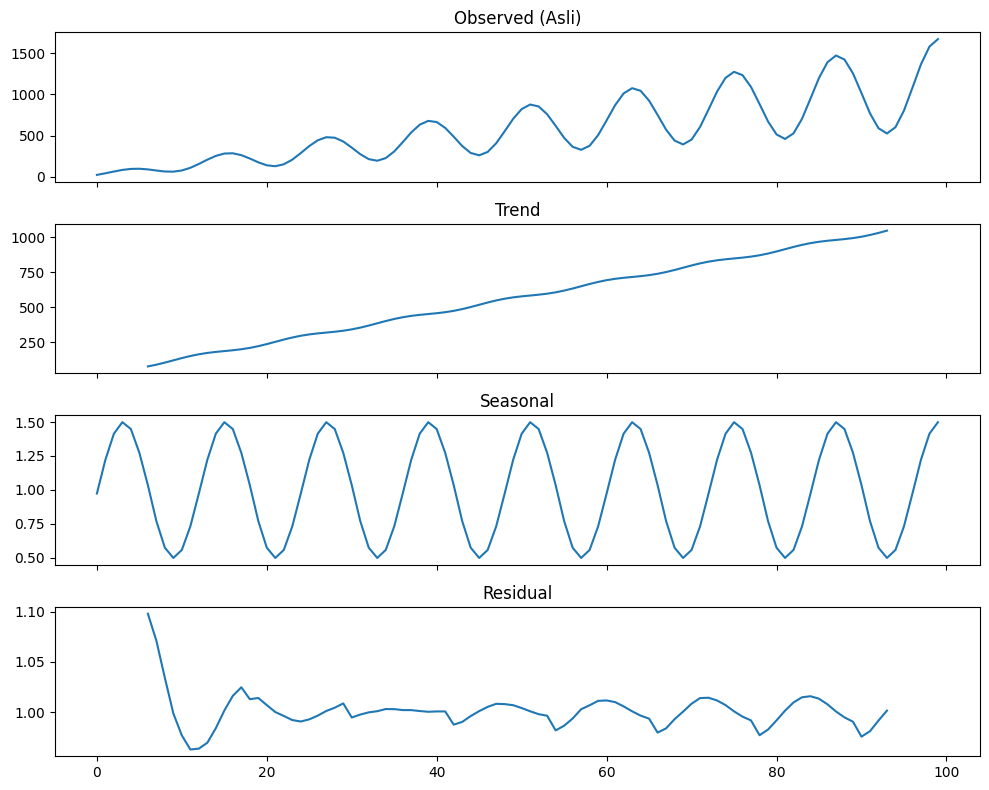

In [91]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?

In [93]:
# Parameter
np.random.seed(1011)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

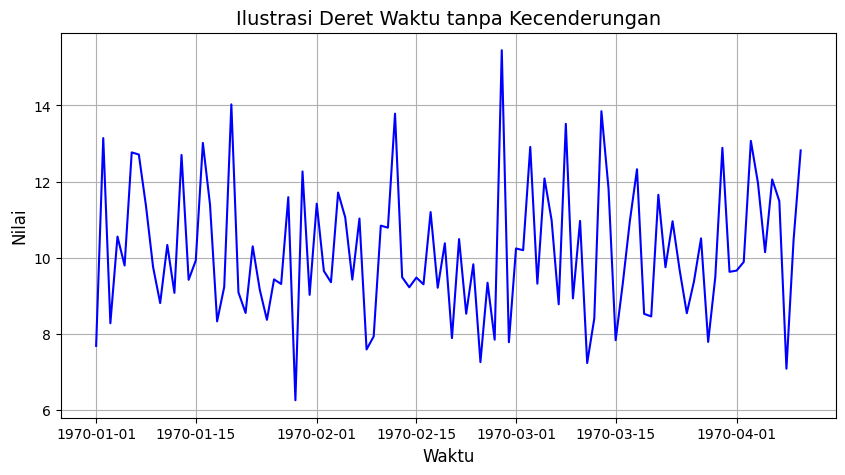

In [94]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

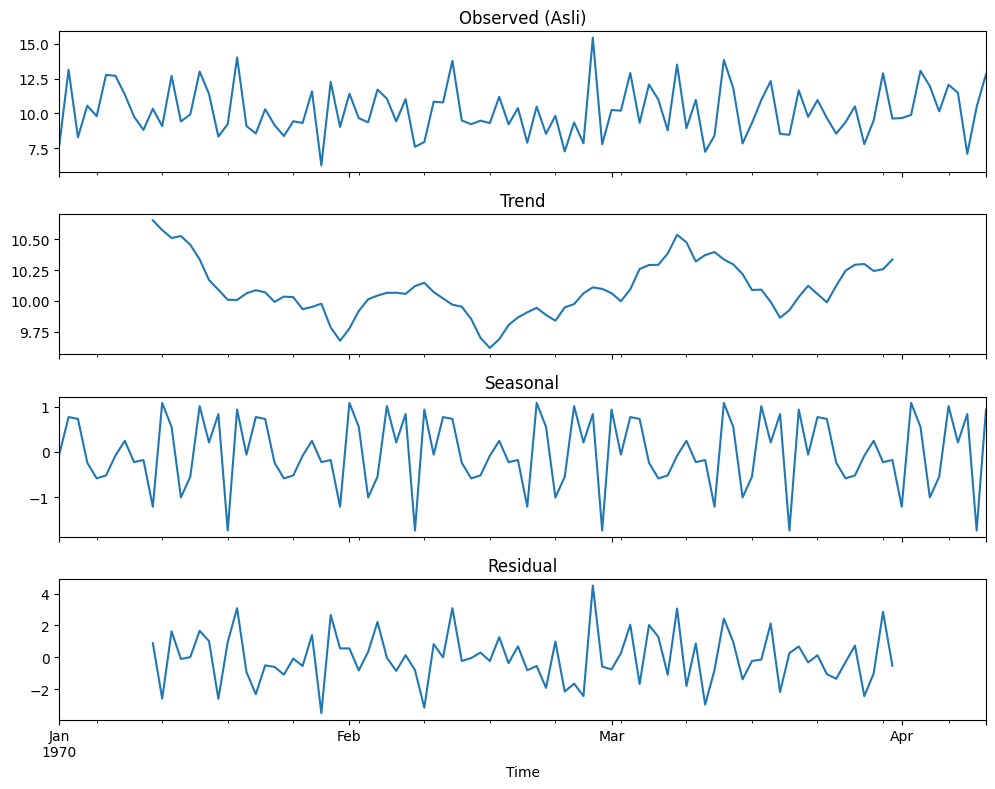

In [95]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?